# Subscription Churn Analysis
**Abubkr Sami | Python and Power BI portfolio project**

Analyze 2,400 subscriptions to understand churn patterns, compare customer segments, and evaluate an interpretable classification baseline.

**Observed outcome:** 223 customers churned (9.29%) and 2,177 were retained. This notebook preserves the supplied exploratory workflow and adds narrative, portable paths, and the explanatory/predictive modeling stages from the companion script.

See the [README](../README.md), [Arabic report](../reports/Subscription_Churn_Analysis_Report_AR.pdf), and [data dictionary](../docs/DATA_DICTIONARY.md). The raw CSV is not distributed here; place it in `data/raw/` or set `CHURN_DATA_PATH`. Saved outputs support read-only review.

The analysis is observational. Feature timing and the future prediction horizon are unspecified, so the model should be treated as exploratory.


## 1. Load the original data
The source contains Arabic column names. The input remains unchanged; transformations are applied to a copy.

In [1]:
from pathlib import Path
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Support launching Jupyter from the repository root or notebooks directory.
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if not (ROOT / "src/Subscription_Churn_Analysis_Code.py").is_file():
    raise FileNotFoundError("Launch this notebook from the repository root or notebooks directory.")
sys.path.insert(0, str(ROOT / "src"))
import Subscription_Churn_Analysis_Code as analysis

DATA_PATH = Path(os.environ.get("CHURN_DATA_PATH", str(ROOT / "data/raw/subscriptions-churn.csv")))
validated = analysis.load_and_clean(DATA_PATH)
df = pd.read_csv(DATA_PATH, encoding="utf-8-sig")
df.head()

,معرف المشترك,تاريخ الاشتراك,الباقة,السعر الشهري,دورة الفوترة,أشهر البقاء,وسيلة الدفع,تذاكر الدعم,متوسط الجلسات الشهرية,نسبة الخصم,حضر التهيئة,ألغى الاشتراك
0,SUB-10000,2025-03-08,متقدم,89.0,شهري,1,بطاقة,1,15,0,نعم,لا
1,SUB-10001,2024-04-17,أعمال,189.0,سنوي,2,محفظة,2,18,0,لا,لا
2,SUB-10002,2025-09-10,متقدم,89.0,شهري,23,تحويل,3,13,0,نعم,لا
3,SUB-10003,2024-06-19,متقدم,89.0,شهري,14,بطاقة,6,28,0,لا,لا
4,SUB-10004,2025-11-24,أعمال,189.0,سنوي,13,محفظة,11,47,0,لا,نعم


In [2]:
df.tail()

,معرف المشترك,تاريخ الاشتراك,الباقة,السعر الشهري,دورة الفوترة,أشهر البقاء,وسيلة الدفع,تذاكر الدعم,متوسط الجلسات الشهرية,نسبة الخصم,حضر التهيئة,ألغى الاشتراك
2395,SUB-12395,2024-12-25,أعمال,189.0,شهري,16,محفظة,4,56,0,نعم,لا
2396,SUB-12396,2025-01-10,أساسي,39.0,سنوي,15,بطاقة,3,15,0,نعم,لا
2397,SUB-12397,2024-06-23,أساسي,39.0,شهري,20,تحويل,1,12,0,لا,لا
2398,SUB-12398,2025-07-08,متقدم,89.0,سنوي,1,تحويل,0,35,0,نعم,لا
2399,SUB-12399,2024-04-25,أعمال,189.0,شهري,28,تحويل,1,36,0,نعم,لا


## 2. Data quality and schema
Check the record count, missing values, duplicate rows, types, and distributions before interpreting the results.

In [3]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum().sort_values(ascending=False))

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nBasic Statistics:")
display(df.describe(include="all").T)

Shape: (2400, 12)

Columns:
['معرف المشترك', 'تاريخ الاشتراك', 'الباقة', 'السعر الشهري', 'دورة الفوترة', 'أشهر البقاء', 'وسيلة الدفع', 'تذاكر الدعم', 'متوسط الجلسات الشهرية', 'نسبة الخصم', 'حضر التهيئة', 'ألغى الاشتراك']

Data Types:
معرف المشترك              object
تاريخ الاشتراك            object
الباقة                    object
السعر الشهري             float64
دورة الفوترة              object
أشهر البقاء                int64
وسيلة الدفع               object
تذاكر الدعم                int64
متوسط الجلسات الشهرية      int64
نسبة الخصم                 int64
حضر التهيئة               object
ألغى الاشتراك             object
dtype: object

Missing Values:
معرف المشترك             0
تاريخ الاشتراك           0
الباقة                   0
السعر الشهري             0
دورة الفوترة             0
أشهر البقاء              0
وسيلة الدفع              0
تذاكر الدعم              0
متوسط الجلسات الشهرية    0
نسبة الخصم               0
حضر التهيئة              0
ألغى الاشتراك            0
dtype: int64

D

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
معرف المشترك,2400,2400,SUB-10000,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
تاريخ الاشتراك,2400,84,2025-05-22,40,NaN,NaN,NaN,NaN,NaN,NaN,NaN
الباقة,2400,3,متقدم,892,NaN,NaN,NaN,NaN,NaN,NaN,NaN
السعر الشهري,2400.0,NaN,NaN,NaN,105.708333,60.823157,39.0,39.0,89.0,189.0,189.0
دورة الفوترة,2400,2,شهري,1493,NaN,NaN,NaN,NaN,NaN,NaN,NaN
أشهر البقاء,2400.0,NaN,NaN,NaN,15.75625,8.627544,1.0,8.0,16.0,23.0,30.0
وسيلة الدفع,2400,3,بطاقة,821,NaN,NaN,NaN,NaN,NaN,NaN,NaN
تذاكر الدعم,2400.0,NaN,NaN,NaN,2.790417,3.167255,0.0,1.0,2.0,4.0,11.0
متوسط الجلسات الشهرية,2400.0,NaN,NaN,NaN,30.20125,16.725449,2.0,16.0,30.0,45.0,59.0
نسبة الخصم,2400.0,NaN,NaN,NaN,3.083333,6.690419,0.0,0.0,0.0,0.0,25.0


## 3. Prepare dates and binary fields
Encode `نعم` as 1 and `لا` as 0. The script validates unexpected values explicitly.

In [4]:
churn_df = validated.copy()
churn_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   معرف المشترك           2400 non-null   object        
 1   تاريخ الاشتراك         2400 non-null   datetime64[ns]
 2   الباقة                 2400 non-null   object        
 3   السعر الشهري           2400 non-null   float64       
 4   دورة الفوترة           2400 non-null   object        
 5   أشهر البقاء            2400 non-null   int64         
 6   وسيلة الدفع            2400 non-null   object        
 7   تذاكر الدعم            2400 non-null   int64         
 8   متوسط الجلسات الشهرية  2400 non-null   int64         
 9   نسبة الخصم             2400 non-null   int64         
 10  حضر التهيئة            2400 non-null   int64         
 11  ألغى الاشتراك          2400 non-null   int64         
dtypes: datetime64[ns](1), float64(1), int64(6), object(4)
memory u

In [5]:
for col in ["الباقة", "دورة الفوترة", "وسيلة الدفع"]:
    print("\n", col)
    print(churn_df[col].value_counts())


 الباقة
الباقة
متقدم    892
أعمال    770
أساسي    738
Name: count, dtype: int64

 دورة الفوترة
دورة الفوترة
شهري    1493
سنوي     907
Name: count, dtype: int64

 وسيلة الدفع
وسيلة الدفع
بطاقة    821
تحويل    793
محفظة    786
Name: count, dtype: int64


## 4. Establish the churn baseline
Only 9.29% of subscribers churned. Accuracy alone would therefore reward a model that never identifies churn.

In [6]:
print(churn_df["ألغى الاشتراك"].value_counts())
print(churn_df["ألغى الاشتراك"].value_counts(normalize=True) * 100)

ألغى الاشتراك
0    2177
1     223
Name: count, dtype: int64
ألغى الاشتراك
0    90.708333
1     9.291667
Name: proportion, dtype: float64


## 5. Compare numeric behavior
Support-ticket demand has the largest numeric difference; use statistical tests and effect sizes below to assess it.

In [7]:
numeric_cols = [
    "السعر الشهري",
    "أشهر البقاء",
    "تذاكر الدعم",
    "متوسط الجلسات الشهرية",
    "نسبة الخصم"
]

comparison = churn_df.groupby("ألغى الاشتراك")[numeric_cols].agg(
    ["mean", "median", "std"]
).round(2)

comparison.T

ألغى الاشتراك                      0      1
السعر الشهري          mean    106.52  97.74
                      median   89.00  89.00
                      std      60.74  61.16
أشهر البقاء           mean     15.73  16.04
                      median   16.00  17.00
                      std       8.63   8.60
تذاكر الدعم           mean      2.66   4.04
                      median    2.00   2.00
                      std       3.07   3.76
متوسط الجلسات الشهرية mean     30.50  27.26
                      median   30.00  26.00
                      std      16.47  18.86
نسبة الخصم            mean      3.10   2.94
                      median    0.00   0.00
                      std       6.72   6.40

## 6. Compare customer segments
Rates summarize associations, not the effect of changing a customer's plan, billing cycle, or onboarding attendance.

In [8]:
categorical_cols = [
    "الباقة",
    "دورة الفوترة",
    "وسيلة الدفع",
    "حضر التهيئة"
]

for col in categorical_cols:
    print(f"\n--- {col} ---")
    
    result = churn_df.groupby(col)["ألغى الاشتراك"].agg(
        العملاء="count",
        الملغين="sum",
        نسبة_الإلغاء="mean"
    )
    
    result["نسبة_الإلغاء"] = (result["نسبة_الإلغاء"] * 100).round(2)
    
    display(result.sort_values("نسبة_الإلغاء", ascending=False))


--- الباقة ---


,العملاء,الملغين,نسبة_الإلغاء
الباقة,,,
أساسي,738,87,11.79
أعمال,770,63,8.18
متقدم,892,73,8.18



--- دورة الفوترة ---


,العملاء,الملغين,نسبة_الإلغاء
دورة الفوترة,,,
شهري,1493,156,10.45
سنوي,907,67,7.39



--- وسيلة الدفع ---


,العملاء,الملغين,نسبة_الإلغاء
وسيلة الدفع,,,
محفظة,786,79,10.05
بطاقة,821,78,9.50
تحويل,793,66,8.32



--- حضر التهيئة ---


,العملاء,الملغين,نسبة_الإلغاء
حضر التهيئة,,,
0,1086,125,11.51
1,1314,98,7.46


## 7. Visualize class imbalance
English display labels keep this chart readable across plotting environments; the underlying data remains Arabic.

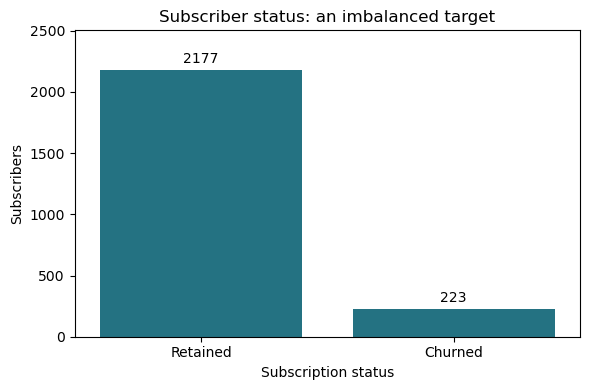

In [9]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(x=churn_df["ألغى الاشتراك"].map({0: "Retained", 1: "Churned"}), color="#147d92")
ax.set(title="Subscriber status: an imbalanced target", xlabel="Subscription status", ylabel="Subscribers")
ax.set_ylim(0, churn_df[analysis.TARGET].value_counts().max() * 1.15)
for container in ax.containers:
    ax.bar_label(container, padding=3)
plt.tight_layout()
plt.show()

## 8. Numeric association tests
Welch's t-test does not assume equal group variances. Cohen's d uses a pooled standard deviation and the difference churned minus retained. The p-values are exploratory and unadjusted for multiple comparisons.

In [10]:
from scipy.stats import ttest_ind, chi2_contingency
import numpy as np
import pandas as pd

# المتغيرات الرقمية
numeric_cols = [
    "السعر الشهري",
    "أشهر البقاء",
    "تذاكر الدعم",
    "متوسط الجلسات الشهرية",
    "نسبة الخصم"
]

results = []

for col in numeric_cols:
    stayed = churn_df.loc[churn_df["ألغى الاشتراك"] == 0, col]
    churned = churn_df.loc[churn_df["ألغى الاشتراك"] == 1, col]

    stat, p = ttest_ind(churned, stayed, equal_var=False)

    # Cohen's d
    pooled_sd = np.sqrt(
        ((len(churned)-1)*churned.std()**2 +
         (len(stayed)-1)*stayed.std()**2)
        /
        (len(churned)+len(stayed)-2)
    )

    d = (churned.mean() - stayed.mean()) / pooled_sd

    results.append([
        col,
        churned.mean(),
        stayed.mean(),
        d,
        p
    ])

numeric_effects = pd.DataFrame(
    results,
    columns=[
        "العامل",
        "متوسط الملغين",
        "متوسط الباقين",
        "Cohens_d",
        "p_value"
    ]
)

numeric_effects.sort_values(
    "Cohens_d",
    key=abs,
    ascending=False
)

,العامل,متوسط الملغين,متوسط الباقين,Cohens_d,p_value
2,تذاكر الدعم,4.044843,2.661920,0.440092,2.401526e-07
3,متوسط الجلسات الشهرية,27.260090,30.502526,-0.194130,1.404616e-02
0,السعر الشهري,97.744395,106.524116,-0.144445,4.203518e-02
1,أشهر البقاء,16.040359,15.727147,0.036298,6.051523e-01
4,نسبة الخصم,2.937220,3.098300,-0.024072,7.220178e-01


## 9. Categorical association tests
Chi-square tests use SciPy's default continuity correction for 2×2 tables. Cramer's V reports association strength.

In [11]:
categorical_cols = [
    "الباقة",
    "دورة الفوترة",
    "وسيلة الدفع",
    "حضر التهيئة"
]

cat_results = []

for col in categorical_cols:

    table = pd.crosstab(
        churn_df[col],
        churn_df["ألغى الاشتراك"]
    )

    chi2, p, dof, expected = chi2_contingency(table)

    n = table.sum().sum()

    cramers_v = np.sqrt(
        chi2 /
        (n * (min(table.shape) - 1))
    )

    cat_results.append([
        col,
        cramers_v,
        p
    ])

categorical_effects = pd.DataFrame(
    cat_results,
    columns=[
        "العامل",
        "Cramers_V",
        "p_value"
    ]
)

categorical_effects.sort_values(
    "Cramers_V",
    ascending=False
)

,العامل,Cramers_V,p_value
3,حضر التهيئة,0.068029,0.000860
0,الباقة,0.057313,0.019415
1,دورة الفوترة,0.049656,0.014990
2,وسيلة الدفع,0.024692,0.481130


## 10. Prepare the Power BI dataset
Export the original Arabic fields plus readable status labels and signup year/month. The generated subscriber-level CSV is ignored by Git.

In [12]:
PBI_PATH = ROOT / "data/processed/subscriptions_churn_clean.csv"
analysis.export_power_bi(churn_df, PBI_PATH)
print("Power BI dataset saved to data/processed/subscriptions_churn_clean.csv")

Power BI dataset saved to data/processed/subscriptions_churn_clean.csv


## 11. Adjusted associations
This explanatory logistic regression uses the full sample to estimate odds ratios and 95% confidence intervals. It is separate from the held-out predictive evaluation. Monthly price is excluded because it is tied to plan in the supplied data. Reference categories are Basic plan, Annual billing, and Transfer payment.

In [13]:
odds_results = analysis.adjusted_odds(churn_df)
odds_results.round(3)

,feature,odds_ratio,ci_lower,ci_upper,p_value
0,tenure_z,1.038,0.901,1.195,0.608
1,support_z,1.481,1.311,1.673,0.000
2,sessions_z,0.784,0.679,0.905,0.001
3,discount_z,0.975,0.846,1.125,0.732
4,onboarding,0.607,0.458,0.805,0.001
5,plan_أعمال,0.676,0.478,0.957,0.027
6,plan_متقدم,0.639,0.458,0.893,0.009
7,billing_شهري,1.481,1.093,2.009,0.011
8,payment_تحويل,0.844,0.595,1.197,0.341
9,payment_محفظة,1.069,0.764,1.497,0.696


## 12. Evaluate the predictive baseline
The pipeline fits scaling and encoding on training data only. A stratified 75/25 split, seed 42, balanced class weights, and the default 0.5 threshold reproduce the supplied script. Average precision is the metric labeled PR-AUC in the PDF.

In [14]:
metrics = analysis.evaluate_model(churn_df)
pd.Series({k: v for k, v in metrics.items() if k != "confusion_matrix"}, name="value")

test_size                   600.000000
test_churned                 56.000000
random_state                 42.000000
decision_threshold            0.500000
accuracy                      0.628333
precision                     0.122172
recall                        0.482143
f1                            0.194946
roc_auc                       0.628118
average_precision             0.135456
always_retained_accuracy      0.906667
test_churn_prevalence         0.093333
Name: value, dtype: float64

In [15]:
pd.DataFrame(metrics["confusion_matrix"], index=["Actual retained", "Actual churned"], columns=["Predicted retained", "Predicted churned"])

,Predicted retained,Predicted churned
Actual retained,350,194
Actual churned,29,27


## 13. Interpret the results
The model detects **27 of 56** churn cases, but produces **194 false positives**. Recall is **48.2%**, precision **12.2%**, and average precision **0.135**. This is an exploratory baseline with limited predictive usefulness.

A practical next step is to test targeted retention outreach for customers with repeated support issues, including onboarding assistance where appropriate. Measure outcomes against a comparison group rather than assuming the observed associations are causal.

**Limitations:** a single random split, unknown feature timing, no defined future churn horizon, and no measured retention uplift. Validate feature availability and use separate validation and temporal test data before operational use.